  Problem 2(b): Shooting Method Solution

Searching for correct initial slope (negative range expected)...
  slope =  -50.0: T(L) - TL =  -512.1568
  slope =  -40.0: T(L) - TL =   402.1884
  slope =  -30.0: T(L) - TL =        inf
  slope =  -20.0: T(L) - TL =        inf
  slope =  -10.0: T(L) - TL =        inf
  slope =    0.0: T(L) - TL =        inf

Bracket found: [-50, -40]


/tmp/ipython-input-714357450.py:19: RuntimeWarning: overflow encountered in scalar power
  d2Tdx2 = alpha * (T - T_inf) + beta * (T**4 - T_inf**4)


  f(-50.00) = -512.1568
  f(-40.00) = 402.1884

Correct initial slope: -41.743985
Converged in 24 iterations

Verification:
  T(0)  = 300.0000  (should be 300.0)
  T(L)  = 399.9999  (should be 400.0)
  T_min = 233.6407  (dip in temperature)

-----------------------------------
x (Length)   | T (Temperature)
-----------------------------------
0.0          | 300.0000       
1.0          | 267.5891       
2.0          | 248.4883       
3.0          | 237.9749       
4.0          | 233.8107       
5.0          | 235.1725       
6.0          | 242.3258       
7.0          | 256.7260       
8.0          | 281.6403       
9.0          | 323.9578       
10.0         | 399.9999       
-----------------------------------


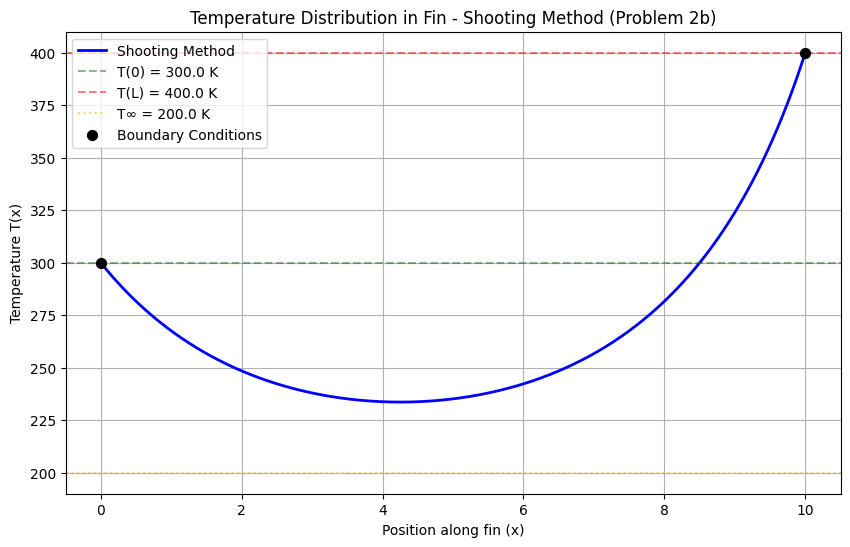

In [1]:
# Problem 2(b): Shooting Method for Fin Heat Transfer BVP
# Solves: d2T/dx2 = alpha*(T - Tinf) + beta*(T^4 - Tinf^4)
# Boundary Conditions: T(0) = T0, T(L) = TL

import numpy as np

# --- Physical Constants ---
L = 10.0        # Length of fin
T0 = 300.0      # Temperature at x = 0
TL = 400.0      # Temperature at x = L
T_inf = 200.0   # Ambient temperature
alpha = 0.05    # Convection parameter
beta = 2.7e-9   # Radiation parameter

# --- Convert 2nd order ODE to system of 1st order ODEs ---
def derivatives(x, y):
    """System of ODEs for fin heat transfer"""
    T, dTdx = y
    d2Tdx2 = alpha * (T - T_inf) + beta * (T**4 - T_inf**4)
    return np.array([dTdx, d2Tdx2])

# --- RK4 Solver ---
def rk4_step(f, x, y, h):
    """Single step of RK4"""
    k1 = f(x, y)
    k2 = f(x + h/2, y + h*k1/2)
    k3 = f(x + h/2, y + h*k2/2)
    k4 = f(x + h, y + h*k3)
    return y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)

def solve_ivp_rk4(f, x_span, y0, n_steps=1000):
    """Solve IVP using RK4"""
    x_start, x_end = x_span
    h = (x_end - x_start) / n_steps

    x_vals = np.linspace(x_start, x_end, n_steps + 1)
    y_vals = np.zeros((n_steps + 1, len(y0)))
    y_vals[0] = y0

    for i in range(n_steps):
        y_vals[i+1] = rk4_step(f, x_vals[i], y_vals[i], h)

    return x_vals, y_vals

# --- Shooting Method ---
def shooting_target(slope_guess):
    """
    Given an initial slope (dT/dx at x=0), integrate to x=L
    and return the error: T(L) - TL
    """
    y0 = np.array([T0, slope_guess])
    x_vals, y_vals = solve_ivp_rk4(derivatives, (0, L), y0, n_steps=1000)
    T_at_L = y_vals[-1, 0]
    return T_at_L - TL

def bisection_method(f, a, b, tol=1e-6, max_iter=100):
    """Bisection method to find root"""
    fa, fb = f(a), f(b)

    print(f"  f({a:.2f}) = {fa:.4f}")
    print(f"  f({b:.2f}) = {fb:.4f}")

    if fa * fb > 0:
        print("Warning: Same sign - trying to find bracket...")
        return None, 0

    for i in range(max_iter):
        c = (a + b) / 2
        fc = f(c)

        if abs(fc) < tol or (b - a) / 2 < tol:
            return c, i + 1

        if fa * fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc

    return c, max_iter

# --- Solve the BVP ---
print("=" * 50)
print("  Problem 2(b): Shooting Method Solution")
print("=" * 50)

# Based on FDM solution: T drops from 300 to ~235 then rises to 400
# This means the INITIAL SLOPE must be NEGATIVE
# Temperature drops about 65K over first 4-5 units before rising

# Search for appropriate bracket
print("\nSearching for correct initial slope (negative range expected)...")

# Try negative slopes (temperature should initially decrease)
slopes_to_try = [-50, -40, -30, -20, -10, 0]
results = []
for s in slopes_to_try:
    err = shooting_target(s)
    results.append((s, err))
    print(f"  slope = {s:6.1f}: T(L) - TL = {err:10.4f}")

# Find the bracket where sign changes
bracket_a, bracket_b = None, None
for i in range(len(results) - 1):
    if results[i][1] * results[i+1][1] < 0:
        bracket_a = results[i][0]
        bracket_b = results[i+1][0]
        break

if bracket_a is not None:
    print(f"\nBracket found: [{bracket_a}, {bracket_b}]")
    correct_slope, iterations = bisection_method(shooting_target, bracket_a, bracket_b)
    print(f"\nCorrect initial slope: {correct_slope:.6f}")
    print(f"Converged in {iterations} iterations")
else:
    print("\nNo bracket found, using best estimate...")
    # Pick slope with smallest absolute error
    best = min(results, key=lambda x: abs(x[1]))
    correct_slope = best[0]
    print(f"Best slope: {correct_slope} with error = {best[1]:.4f}")

# Solve with the correct initial slope
y0_final = np.array([T0, correct_slope])
x_solution, y_solution = solve_ivp_rk4(derivatives, (0, L), y0_final, n_steps=1000)

# Verification
print(f"\nVerification:")
print(f"  T(0)  = {y_solution[0, 0]:.4f}  (should be {T0})")
print(f"  T(L)  = {y_solution[-1, 0]:.4f}  (should be {TL})")
print(f"  T_min = {np.min(y_solution[:, 0]):.4f}  (dip in temperature)")

# --- Print Results at node points ---
print("\n" + "-" * 35)
print(f"{'x (Length)':<12} | {'T (Temperature)':<15}")
print("-" * 35)

# Print at 11 evenly spaced points
for i in range(11):
    idx = i * 100  # 1000 steps / 10 intervals = 100
    print(f"{x_solution[idx]:<12.1f} | {y_solution[idx, 0]:<15.4f}")
print("-" * 35)

# Plot
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 6))
    plt.plot(x_solution, y_solution[:, 0], 'b-', linewidth=2, label='Shooting Method')
    plt.axhline(T0, color='g', linestyle='--', alpha=0.5, label=f'T(0) = {T0} K')
    plt.axhline(TL, color='r', linestyle='--', alpha=0.5, label=f'T(L) = {TL} K')
    plt.axhline(T_inf, color='orange', linestyle=':', alpha=0.5, label=f'T∞ = {T_inf} K')
    plt.scatter([0, L], [T0, TL], color='black', s=50, zorder=5, label='Boundary Conditions')
    plt.xlabel('Position along fin (x)')
    plt.ylabel('Temperature T(x)')
    plt.title('Temperature Distribution in Fin - Shooting Method (Problem 2b)')
    plt.legend()
    plt.grid(True)
    plt.show()
except ImportError:
    print("\n(matplotlib not available for plotting)")